<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-05/classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 05 — Classification: predicting categories

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
1. Frame a **binary classification** problem and split data into train/test.
2. Train **Logistic Regression** and **k-Nearest Neighbors** with `scikit-learn`,
   using a **preprocessing pipeline** (feature scaling).
3. Read a **confusion matrix** and metrics: accuracy, precision, recall, F1.
4. Recognize **class imbalance** and why accuracy alone can mislead.

## The task
Using daily weather for **Maceió/AL** ([card](../../datasets/maceio_daily_weather.DATASET.md)),
predict whether a day **had rain** (`rained = 1`, precipitation ≥ 1 mm) from that
day's other measurements (temperature, humidity, pressure, wind, solar radiation,
month).

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

wx = load_dataset("maceio_daily_weather.csv")
print("rows:", len(wx))
print("rain-day rate:", round(wx['rained'].mean(), 3), "<- note the imbalance")
wx.head()

rows: 5479
rain-day rate: 0.684 <- note the imbalance


,date,temp_max_c,temp_min_c,temp_mean_c,precip_mm,wind_max_kmh,solar_rad_mj_m2,humidity_pct,pressure_hpa,month,rained
0,2010-01-01,28.2,24.3,26.0,2.0,19.5,20.11,82,1011.0,1,1
1,2010-01-02,28.4,24.0,26.1,3.8,18.3,22.74,81,1011.3,1,1
2,2010-01-03,28.7,23.5,26.0,1.0,20.2,23.97,81,1011.9,1,1
3,2010-01-04,28.6,23.6,26.1,1.2,15.2,22.00,81,1012.7,1,1
4,2010-01-05,28.1,24.0,25.9,2.8,14.1,14.48,82,1012.0,1,1


### 1. Define features `X` and target `y`

We deliberately **exclude `precip_mm`** — it is the quantity used to define the
label, so including it would be *leakage* (cheating). A good predictor must work
from variables known *without* already measuring the rain.

In [3]:
features = ["temp_max_c", "temp_min_c", "temp_mean_c", "humidity_pct",
            "pressure_hpa", "wind_max_kmh", "solar_rad_mj_m2", "month"]
X = wx[features].values
y = wx["rained"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
print("train:", X_train.shape, " test:", X_test.shape)

train: (4109, 8)  test: (1370, 8)


### 2. A baseline first

Before any model, ask: *what does trivial guessing achieve?* If 68% of days are
rainy, always predicting "rain" already scores 68% accuracy. Any model must beat
this **majority-class baseline** to be useful.

In [4]:
baseline = max(y_train.mean(), 1 - y_train.mean())
print(f"majority-class baseline accuracy = {baseline:.3f}")

majority-class baseline accuracy = 0.684


### 3. Logistic Regression

Logistic regression models the **probability** of the positive class. We wrap it
in a pipeline with `StandardScaler` so all features are on a comparable scale.

In [5]:
logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
logreg.fit(X_train, y_train)
pred_lr = logreg.predict(X_test)
print(f"Logistic Regression accuracy = {accuracy_score(y_test, pred_lr):.3f}")
print()
print(classification_report(y_test, pred_lr, target_names=["no rain", "rain"]))

Logistic Regression accuracy = 0.807

              precision    recall  f1-score   support

     no rain       0.71      0.65      0.68       434
        rain       0.84      0.88      0.86       936

    accuracy                           0.81      1370
   macro avg       0.78      0.76      0.77      1370
weighted avg       0.80      0.81      0.80      1370



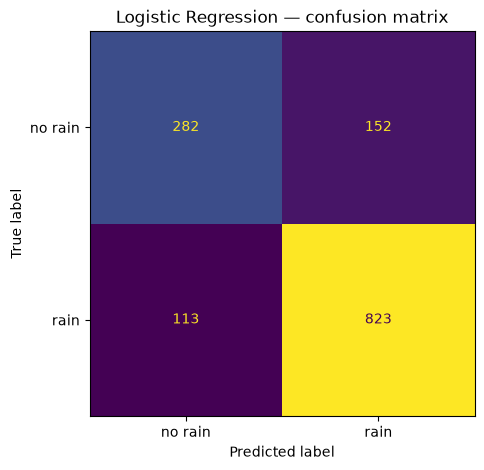

In [6]:
cm = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm, display_labels=["no rain", "rain"]).plot(colorbar=False)
plt.title("Logistic Regression — confusion matrix"); plt.show()

### 4. k-Nearest Neighbors

A completely different idea: classify a day by the **majority vote of the `k`
most similar days**. Scaling matters even more here, since k-NN uses distances.

In [7]:
knn = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=15))
knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print(f"k-NN (k=15) accuracy = {accuracy_score(y_test, pred_knn):.3f}")
print(classification_report(y_test, pred_knn, target_names=["no rain", "rain"]))

k-NN (k=15) accuracy = 0.812
              precision    recall  f1-score   support

     no rain       0.74      0.62      0.68       434
        rain       0.84      0.90      0.87       936

    accuracy                           0.81      1370
   macro avg       0.79      0.76      0.77      1370
weighted avg       0.81      0.81      0.81      1370



### 5. Why accuracy is not enough

With 68% rainy days, **recall for the *no-rain* class** is what's hard. Look at
precision/recall per class above: the models are much better at spotting rain
than dry days. In an imbalanced problem you must report **per-class** metrics,
not just overall accuracy. We dig deeper into evaluation (cross-validation, ROC,
overfitting) in **lecture 06**.

### Exercises
1. Sweep `k` in k-NN over `[1, 5, 15, 31, 61]`. Plot test accuracy vs. `k`. What
   happens at `k = 1` and why?
2. Drop `humidity_pct` from the features and retrain logistic regression. How much
   does performance fall? What does that tell you about that feature?
3. Logistic regression exposes `predict_proba`. Change the decision threshold from
   0.5 to 0.7 for the "rain" class. How do precision and recall trade off?
4. **Discuss:** for a farmer deciding whether to irrigate, is a *false "rain"*
   (predicting rain when it stays dry) or a *false "no-rain"* worse? How should
   that change which metric you optimize?